<h1 style="color:orange"> Compilation and analysis of scientific trends in the context of High Energy Physics and Gravitation with NLP. </h1>

<h1 style="color:yellow"> Introduction </h1>

### 1. Motivation and Context

The arXiv preprint repository (arxiv.org) is the primary dissemination platform for research in physics, mathematics, computer science, and related fields. With over two million articles, it offers a rich source of structured and unstructured data for understanding scientific production, collaboration patterns, and the evolution of research topics. Analysing arXiv metadata allows researchers and data scientists to answer questions such as:

- How has the volume of publications evolved over time?
- Which authors are most prolific in a given domain?
- What are the dominant keywords and emerging topics?
- Can we automatically classify an article’s primary category from its title and abstract?

This project focuses on two high‑energy physics sections: **hep‑th** (High Energy Physics – Theory) and **gr‑qc** (General Relativity and Quantum Cosmology). The time span covers **2015–2025**, capturing a decade of recent research, including the rise of gravitational‑wave astronomy and developments in holography.

### 2. Methodology

The project is divided into four parts, each building on the previous one:

#### Part 1 – Data Collection
Using the **arXiv API**, we queried all articles submitted between 2015 and 2025 with primary or secondary categories in `hep-th` or `gr-qc`. The API returns XML metadata (title, abstract, authors, submission date, categories). We respected the rate limit (one request every three seconds) and implemented pagination. The raw data was saved as a CSV file.

#### Part 2 – Cleaning and Storage
- **Deduplication**: Articles were deduplicated by `arxiv_id` and, secondarily, by `(title, authors)`.
- **Date parsing**: The `published` field was converted to datetime, and year/month columns were extracted.
- **Category handling**: The `primary_category` was isolated; multiple categories were kept as a comma‑separated string.
- **SQLite database**: The cleaned data was stored in a local SQLite database (`arxiv.db`) to practice querying and enable efficient filtering.

#### Part 3 – Exploratory Analysis and Visualisation
We generated several visualisations:
- Time series of articles per year.
- Stacked bar chart of primary category distribution.
- Top 10 most prolific authors.
- Word clouds from titles and abstracts.
- Trend lines for selected keywords (`black hole`, `string`, `gravity`, `quantum`, `cosmology`, `AdS`, `CFT`, `holography`).

#### Part 4 – Text Classification (NLP)
To demonstrate machine learning on textual data, we built a classifier that predicts the **primary category** from the concatenated title and abstract. Steps included:
- Text cleaning (lowercase, removal of punctuation and extra spaces).
- TF‑IDF vectorisation (unigrams and bigrams, max 5000 features).
- Training of **Logistic Regression** (multinomial) and **Random Forest**.
- Evaluation using accuracy and classification report.

The best performing model was **Logistic Regression**, with an accuracy of **~77%** (depending on the chosen categories). This shows that simple linear models already capture meaningful lexical patterns associated with different research domains.

### 3. Tools and Libraries

- **Data collection**: `requests`, `xml.etree.ElementTree`, `time`
- **Data manipulation**: `pandas`, `re`, `json`
- **Database**: `sqlite3`
- **Visualisation**: `matplotlib`, `seaborn`, `wordcloud`
- **Machine learning**: `scikit-learn` (TF‑IDF, Logistic Regression, Random Forest)
- **Serialisation**: `joblib` (for saving model and vectoriser)

### 4. Limitations and Future Directions

The current analysis is restricted to articles that explicitly list `hep-th` or `gr-qc` among their categories. Furthermore, only categories with at least 100 samples were kept for classification, which reduces the number of classes. A more ambitious project would:

- Include **all categories** from physics and even cross‑disciplinary articles.
- Extend the time window to **1991–2025** to capture the full history of arXiv.
- Use **deep learning** (e.g., fine‑tuned BERT) for improved classification accuracy.
- Analyse **citation data** (via Crossref or Inspire) to measure impact.

Nevertheless, this project provides a solid foundation for anyone wishing to explore academic metadata, practice data engineering, and apply NLP to real‑world scientific texts.



<h1 style="color:yellow">Part 1: Data Compilation </h1>

In [1]:
import requests
import time
import pandas as pd
import xml.etree.ElementTree as ET
from typing import List, Dict
import logging
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import re
from datetime import datetime

In [2]:
# Logging configuration
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Params
CATEGORIES = ['hep-th', 'gr-qc']
START_YEAR = 2025
END_YEAR = 2025
MAX_RESULTS_PER_QUERY = 100  # max num allowed for API
SLEEP_INTERVAL = 4  # segs, request by ArXiv

In [3]:
def build_query(category: str, start_date: str, end_date: str, start_idx: int = 0) -> str:
    """
    Build the query for arxiv API
    Date format: YYYYMMDD
    """
    return f"http://export.arxiv.org/api/query?search_query=cat:{category}+AND+submittedDate:[{start_date}+TO+{end_date}]&start={start_idx}&max_results={MAX_RESULTS_PER_QUERY}"

def fetch_articles(query: str) -> ET.Element:
    """
    Execute the request and return the XML root element
    """
    response = requests.get(query)
    if response.status_code == 200:
        return ET.fromstring(response.content)
    else:
        logging.error(f"Error {response.status_code}: {response.text}")
        return None

In [4]:
def parse_entry(entry: ET.Element) -> Dict:
    """
    Extract fields from <entry> element for arXiv
    """
    # Define the necesary namespaces 
    ns = {
        'atom': 'http://www.w3.org/2005/Atom',      # standard namespace for Atom
        'arxiv': 'http://arxiv.org/schemas/atom'    # specific extensions for ArXive
    }
    
    def text_or_empty(element, path):
        elem = element.find(path, ns)
        return elem.text if elem is not None else ''
    
    # article ID
    arxiv_id = text_or_empty(entry, 'atom:id').split('/abs/')[-1]
    
    # Title
    title = text_or_empty(entry, 'atom:title').replace('\n', ' ').strip()
    
    # Summary
    summary = text_or_empty(entry, 'atom:summary').replace('\n', ' ').strip()
    
    # Publish date
    published = text_or_empty(entry, 'atom:published')
    
    # Authors (can be several)
    authors = []
    for author in entry.findall('atom:author', ns):
        name_elem = author.find('atom:name', ns)
        if name_elem is not None and name_elem.text:
            authors.append(name_elem.text)
    
    # Categories (can be several)
    categories = []
    for cat in entry.findall('atom:category', ns):
        term = cat.attrib.get('term', ' ')
        if term:
            categories.append(term)
    
    return {
        'arxiv_id': arxiv_id,
        'title': title,
        'summary': summary,
        'published': published,
        'authors': ', '.join(authors) if authors else '',
        'num_authors': len(authors),
        'categories': ', '.join(categories) if categories else '',
        'primary_category': categories[0] if categories else ''
    }

In [11]:
# Test (2 articles)
test_query = "http://export.arxiv.org/api/query?search_query=cat:hep-th&start=0&max_results=5"
root = fetch_articles(test_query)
entries = root.findall('{http://www.w3.org/2005/Atom}entry')

for entry in entries[:2]:  # First 2
    parsed = parse_entry(entry)
    print(parsed)

{'arxiv_id': '2012.11536v1', 'title': 'Quantum geometric maps and their properties', 'summary': 'Quantum geometric maps, which relate SU(2) spin networks and Lorentz covariant projected spin networks, are an important ingredient of spin foam models (and tensorial group field theories) for 4-dimensional quantum gravity. We give a general definition of such maps, that encompasses all current spin foam models, and we investigate their properties at such a general level. We then specialize the definition to see how the precise implementation of simplicity constraints affects features of the quantum geometric maps in specific models.', 'published': '2020-12-21T17:56:33Z', 'authors': 'Marco Finocchiaro, Yoobin Jeong, Daniele Oriti', 'num_authors': 3, 'categories': 'gr-qc, hep-th, math-ph', 'primary_category': 'gr-qc'}
{'arxiv_id': '2012.10103v1', 'title': 'A proposal for Heisenberg uncertainty principle and STUR for curved backgrounds: an application to white dwarf, neutron stars and black h

In [16]:
#all_articles = []

for category in CATEGORIES:
    for year in range(START_YEAR, END_YEAR + 1):
        start_date = f"{year}0101"
        end_date = f"{year}1231"
        start_idx = 0
        total_fetched = 0
        
        logging.info(f"Scraping {category} year {year}")
        
        while True:
            query = build_query(category, start_date, end_date, start_idx)
            root = fetch_articles(query)
            if root is None:
                break
            
            # Search element <opensearch:totalResults>
            total_results_elem = root.find('{http://a9.com/-/spec/opensearch/1.1/}totalResults')
            total_results = int(total_results_elem.text) if total_results_elem is not None else 0
            
            entries = root.findall('{http://www.w3.org/2005/Atom}entry')
            for entry in entries:
                all_articles.append(parse_entry(entry))
            
            total_fetched += len(entries)
            logging.info(f"  Get {total_fetched}/{total_results} articles...")
            
            if total_fetched >= total_results:
                break
            start_idx += MAX_RESULTS_PER_QUERY
            time.sleep(SLEEP_INTERVAL)
        
        # Pause between years
        time.sleep(SLEEP_INTERVAL)

2026-04-20 21:15:43,820 - INFO - Scraping hep-th year 2025
2026-04-20 21:15:44,028 - INFO -   Get 100/8159 articles...
2026-04-20 21:15:48,222 - INFO -   Get 200/8159 articles...
2026-04-20 21:15:52,444 - INFO -   Get 300/8159 articles...
2026-04-20 21:15:56,651 - INFO -   Get 400/8159 articles...
2026-04-20 21:16:00,840 - INFO -   Get 500/8159 articles...
2026-04-20 21:16:05,056 - INFO -   Get 600/8159 articles...
2026-04-20 21:16:09,281 - INFO -   Get 700/8159 articles...
2026-04-20 21:16:13,466 - INFO -   Get 800/8159 articles...
2026-04-20 21:16:17,640 - INFO -   Get 900/8159 articles...
2026-04-20 21:16:21,822 - INFO -   Get 1000/8159 articles...
2026-04-20 21:16:26,017 - INFO -   Get 1100/8159 articles...
2026-04-20 21:16:30,200 - INFO -   Get 1200/8159 articles...
2026-04-20 21:16:34,392 - INFO -   Get 1300/8159 articles...
2026-04-20 21:16:38,577 - INFO -   Get 1400/8159 articles...
2026-04-20 21:16:42,778 - INFO -   Get 1500/8159 articles...
2026-04-20 21:16:46,974 - INFO -   

In [18]:
df = pd.DataFrame(all_articles)
df.to_csv('arxiv_metadata_raw.csv', index=False)
print(f"Total de artículos recolectados: {len(df)}")

Total de artículos recolectados: 102582


In [19]:
df.tail()

,arxiv_id,title,summary,published,authors,num_authors,categories,primary_category
102577,2510.07390v3,Heterotic Footprints in Classical Gravity: PM ...,We study classical scattering of charged black...,2025-10-08T18:00:06Z,"Arpan Bhattacharyya, Saptaswa Ghosh, Ankit Mis...",4,"hep-th, gr-qc, hep-ph",hep-th
102578,2512.06908v2,A first-order formulation of f(R) gravity in s...,"We develop an augmented characteristic, first-...",2025-12-07T16:25:30Z,"Philippe G. LeFloch, Filipe C. Mena",2,"gr-qc, math.AP",gr-qc
102579,2511.21504v2,Entanglement Entropy of a Non-Minimally Couple...,We compute the first-order correction in the q...,2025-11-26T15:38:55Z,Florin Manea,1,"gr-qc, hep-th, math-ph",gr-qc
102580,2510.08832v1,Distinguishing between Black Holes and Neutron...,We study the ability of tidal signatures withi...,2025-10-09T21:33:35Z,"Michael Müller, Reed Essick",2,"gr-qc, astro-ph.HE",gr-qc
102581,2507.23667v2,Universal Time Evolution of Holographic and Qu...,"Holographic complexity, as the bulk dual of qu...",2025-07-31T15:47:34Z,"Masamichi Miyaji, Shan-Ming Ruan, Shono Shibuy...",4,"hep-th, gr-qc",hep-th


<h1 style="color:yellow"> Part 2. SQL DB and Data Cleaning</h1>

In [3]:

## Data Upload
df = pd.read_csv('arxiv_metadata_raw.csv')
print(f'Number of entries: {len(df)}')
df.head()

Number of entries: 102582


,arxiv_id,title,summary,published,authors,num_authors,categories,primary_category
0,1501.01153v3,"Bag model of hadrons, dual QCD thermodynamics ...",Using the grand canonical ensemble formulation...,2015-01-06T11:39:11Z,"H. C. Chandola, Garima Punetha, H. Dehnen",3,"hep-ph, hep-th",hep-ph
1,1501.01205v5,A unified field theory I: The quantization of ...,In a former paper we proposed a model for the ...,2015-01-05T19:55:09Z,Claus Gerhardt,1,"gr-qc, hep-th, math-ph, math.DG",gr-qc
2,1501.01628v2,"A few recent developments in 2d (2,2) and (0,2...",In this note we summarize a few of the many re...,2015-01-07T21:00:09Z,E. Sharpe,1,hep-th,hep-th
3,1501.01642v1,Anisotropies in Non-Thermal Distortions of Cos...,Ultralight axions which couple sufficiently st...,2015-01-07T21:02:49Z,"Guido D'Amico, Nemanja Kaloper",2,"astro-ph.CO, astro-ph.HE, gr-qc, hep-ph, hep-th",astro-ph.CO
4,1501.01700v2,Uncertainty relation in Schwarzschild spacetime,We explore the entropic uncertainty relation i...,2015-01-08T01:18:50Z,"Jun Feng, Yao-Zhong Zhang, Mark D. Gould, Heng...",4,"hep-th, quant-ph",hep-th


In [4]:
# Duplicates cleaning
initial_len = len(df)
df = df.drop_duplicates(subset=['arxiv_id'], keep='first')
print(f'Drop {initial_len-len(df)} suplicates for arxiv_id')

df = df.drop_duplicates(subset=['title'], keep='first')
print(f'Final number of articles: {len(df)}')

Drop 21527 suplicates for arxiv_id
Number of articles: 81011


In [5]:
# Published to datetime conversion (ISO 8610 format)
df['published'] = pd.to_datetime(df['published'], errors='coerce')
df['year'] = df['published'].dt.year
df['month'] = df['published'].dt.month

# Drop files with null date
df = df.dropna(subset=['published'])
print(f'Final number of articles: {len(df)}')

Final number of articles: 81011


In [9]:
# Cleaning in title and summary
df['title'] = df['title'].str.replace('\n', ' ').str.strip()
df['summary'] = df['summary'].str.replace('\n', ' ').str.strip()

In [10]:
# List of categories
df['category_list'] = df['categories'].apply(lambda x: x.split(', ') if pd.notna(x) else [])

In [13]:
df.head()

,arxiv_id,title,summary,published,authors,num_authors,categories,primary_category,year,month,category_list
0,1501.01153v3,"Bag model of hadrons, dual QCD thermodynamics ...",Using the grand canonical ensemble formulation...,2015-01-06 11:39:11+00:00,"H. C. Chandola, Garima Punetha, H. Dehnen",3,"hep-ph, hep-th",hep-ph,2015,1,"[hep-ph, hep-th]"
1,1501.01205v5,A unified field theory I: The quantization of ...,In a former paper we proposed a model for the ...,2015-01-05 19:55:09+00:00,Claus Gerhardt,1,"gr-qc, hep-th, math-ph, math.DG",gr-qc,2015,1,"[gr-qc, hep-th, math-ph, math.DG]"
2,1501.01628v2,"A few recent developments in 2d (2,2) and (0,2...",In this note we summarize a few of the many re...,2015-01-07 21:00:09+00:00,E. Sharpe,1,hep-th,hep-th,2015,1,[hep-th]
3,1501.01642v1,Anisotropies in Non-Thermal Distortions of Cos...,Ultralight axions which couple sufficiently st...,2015-01-07 21:02:49+00:00,"Guido D'Amico, Nemanja Kaloper",2,"astro-ph.CO, astro-ph.HE, gr-qc, hep-ph, hep-th",astro-ph.CO,2015,1,"[astro-ph.CO, astro-ph.HE, gr-qc, hep-ph, hep-th]"
4,1501.01700v2,Uncertainty relation in Schwarzschild spacetime,We explore the entropic uncertainty relation i...,2015-01-08 01:18:50+00:00,"Jun Feng, Yao-Zhong Zhang, Mark D. Gould, Heng...",4,"hep-th, quant-ph",hep-th,2015,1,"[hep-th, quant-ph]"


In [15]:
# SQL DB

df_sql = df.copy()
import json
if 'category_list' in df_sql.columns:
    df_sql['category_list'] = df_sql['category_list'].apply(json.dumps)

## Connection
conn = sqlite3.connect('arxiv.db')

## Clean DataFrame saved in table called 'articles'
df_sql.to_sql('articles', conn, if_exists='replace', index=False)
print('articles table created in arxiv.db')
conn.close()

articles table created in arxiv.db


In [16]:
## SQL_lite queries

## Number of articles per year and primary category
conn = sqlite3.connect('arxiv.db')
query1 = """
SELECT year, primary_category, COUNT(*) as count
FROM articles
GROUP BY year, primary_category
ORDER BY year, count DESC
"""
result1 = pd.read_sql(query1, conn)
print(result1.head(10))


   year    primary_category  count
0  2015              hep-th   3702
1  2015               gr-qc    973
2  2015              hep-ph    480
3  2015         astro-ph.CO    242
4  2015             math-ph    234
5  2015            quant-ph    140
6  2015             hep-lat     90
7  2015     cond-mat.str-el     83
8  2015  cond-mat.stat-mech     71
9  2015   cond-mat.mes-hall     47


In [18]:
## Number of articles per year
query1_2 = """
SELECT year, COUNT(*) as count
FROM articles
GROUP BY year
ORDER BY count DESC
"""
result1_2 = pd.read_sql(query1_2, conn)
result1_2

,year,count
0,2025,12231
1,2024,7780
2,2023,7303
3,2020,7209
4,2022,7164
5,2021,7120
6,2019,6843
7,2018,6450
8,2017,6333
9,2015,6322


In [21]:
# Top 10 authors with more articles
query2= """
SELECT authors, COUNT(*) as count
FROM articles
GROUP BY authors
ORDER BY count DESC
LIMIT 20
"""
result2 = pd.read_sql(query2, conn)
result2

,authors,count
0,Shahar Hod,117
1,Massimo Giovannini,58
2,J. Kluson,52
3,"S. D. Odintsov, V. K. Oikonomou",46
4,Dibakar Roychowdhury,45
5,Yu Nakayama,40
6,J. S. Dowker,40
7,Ichiro Oda,37
8,V. K. Oikonomou,36
9,Yan Peng,35


   year  month  count
0  2015      1    428
1  2015      2    463
2  2015      3    518
3  2015      4    501
4  2015      5    518


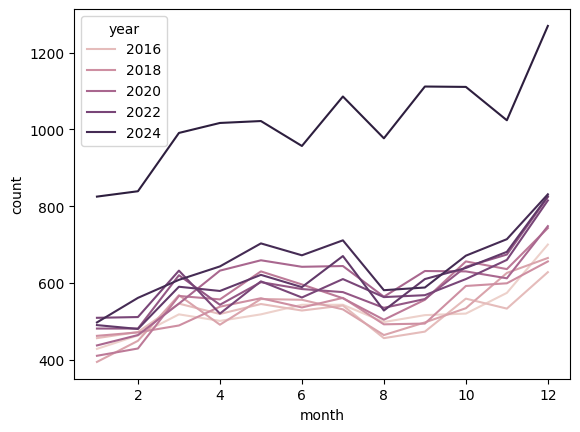

In [27]:
# Articles per month (temporal series)
query3 = """
SELECT year, month, COUNT(*) as count
FROM articles
GROUP BY year, month
ORDER BY year, month
"""
result3 = pd.read_sql(query3, conn)

print(result3.head())
sns.lineplot(data = result3, x='month', y='count', hue='year')
plt.show()

In [28]:
# More frequent words in titles
titles = df['title'].dropna()

from collections import Counter
import re

word_pattern = re.compile(r'\b[a-zA-Z]{3,}\b')
all_words = []
for title in titles:
    words = word_pattern.findall(title.lower())
    all_words.extend(words)

common = Counter(all_words).most_common(20)
print('More frequent words in titles:')
for word, count in common:
    print(f' {word}: {count}')

More frequent words in titles:
 the: 28219
 and: 27864
 for: 9593
 black: 8487
 quantum: 8421
 from: 8041
 with: 7993
 theory: 7742
 gravity: 7506
 field: 5822
 holes: 4368
 non: 4337
 model: 4233
 theories: 3818
 hole: 3806
 gravitational: 3555
 gauge: 3209
 scalar: 2935
 holographic: 2736
 models: 2709


In [29]:
df.to_csv('arxiv_cleaned.csv', index=False)
print("Cleaned version saves as arxiv_cleaned.csv")

Cleaned version saves as arxiv_cleaned.csv


In [30]:
conn.close()
print("Conexion closed.")

Conexion closed.


<h1 style="color:yellow"> Part 3: Data Visualization and Exploratory Analysis</h1>

In [2]:
from wordcloud import WordCloud

In [5]:
# Graphic style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [8]:
conn = sqlite3.connect('arxiv.db')
df = pd.read_sql("SELECT * FROM articles", conn)
conn.close()

print(f'Dataset load: {df.shape[0]} rows, and {df.shape[1]} columns.')

Dataset load: 81011 rows, and 11 columns.


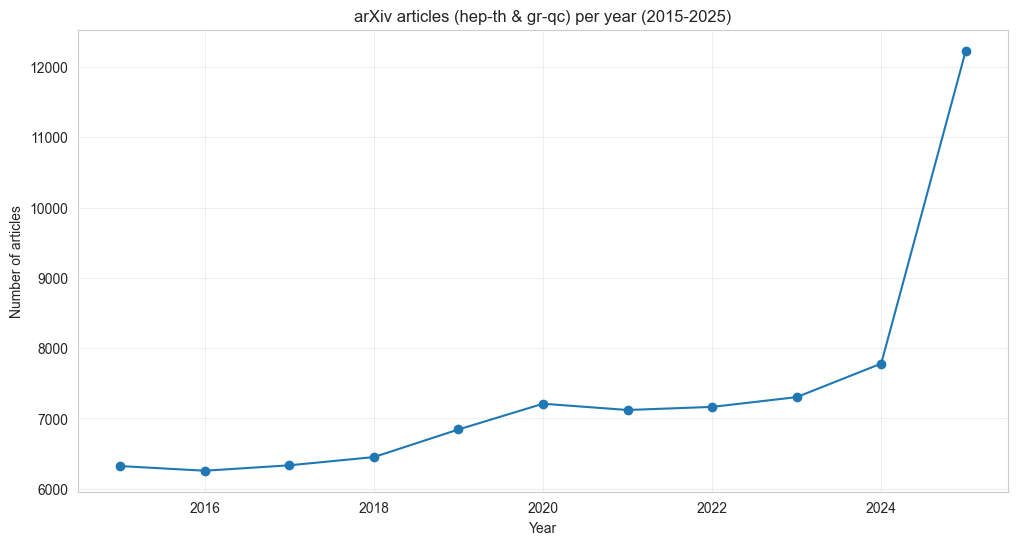

In [36]:
# Count per year
yearly_counts = df['year'].value_counts().sort_index()

plt.figure()
plt.plot(yearly_counts.index, yearly_counts.values, marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Number of articles')
plt.title('arXiv articles (hep-th & gr-qc) per year (2015-2025)')
plt.grid(alpha=0.3)
plt.show()

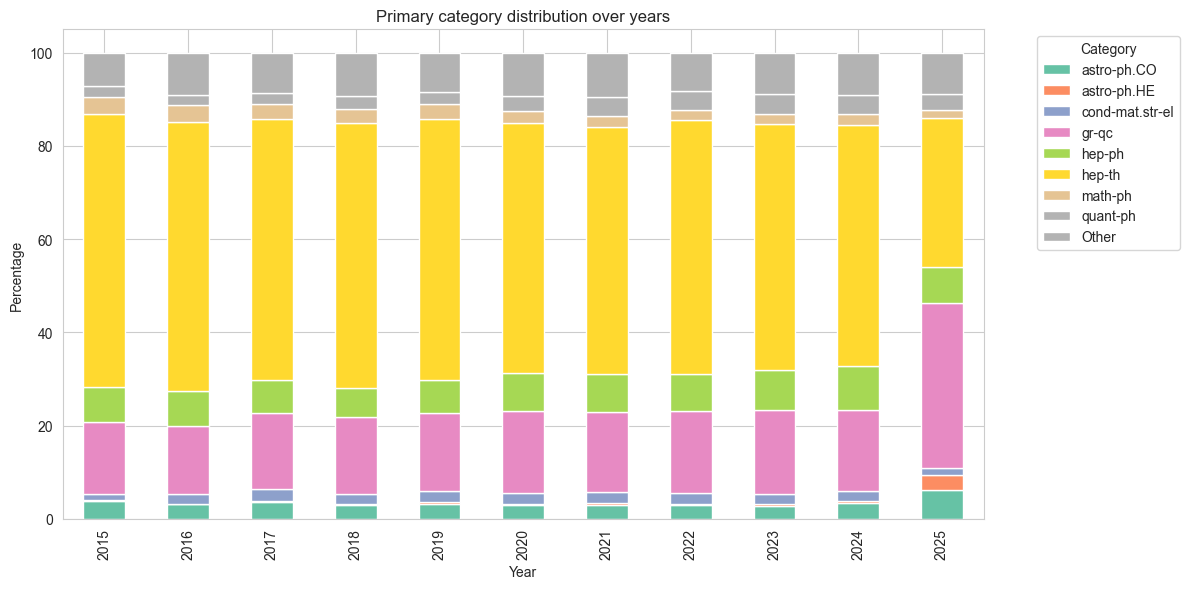

In [39]:
# Articles per year and primary category 
## Cross-table
pivot_pct = pd.crosstab(df['year'],df['primary_category'],normalize='index') * 100

## Threshols of category importance
threshold = 2.0

## Principal categories
main_cats = []
for col in pivot_pct.columns:
    if (pivot_pct[col] > threshold).any():
        main_cats.append(col)

## Copy with 'Other' column for non-principal categories
pivot_grouped = pivot_pct[main_cats].copy()
pivot_grouped['Other'] = pivot_pct[[c for c in pivot_pct.columns if c not in main_cats]].sum(axis=1)


pivot_grouped.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.title('Primary category distribution over years')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

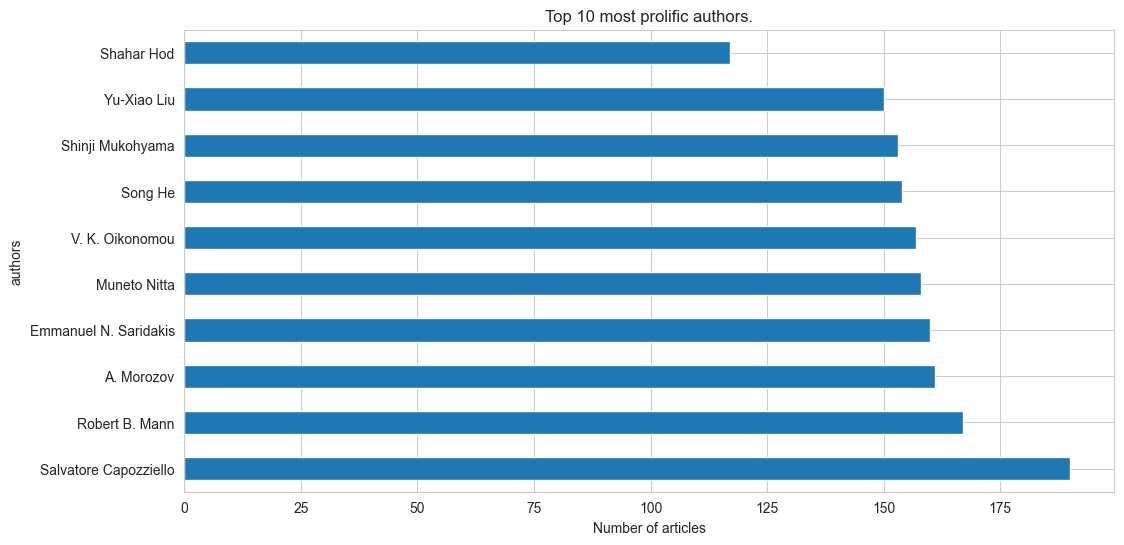

In [9]:
## Top 10 authors
author_counts = df['authors'].str.split(', ').explode().value_counts().head(10)

plt.figure()
author_counts.plot(kind='barh')
plt.xlabel('Number of articles')
plt.title('Top 10 most prolific authors.')
plt.gca().invert_yaxis
plt.show()

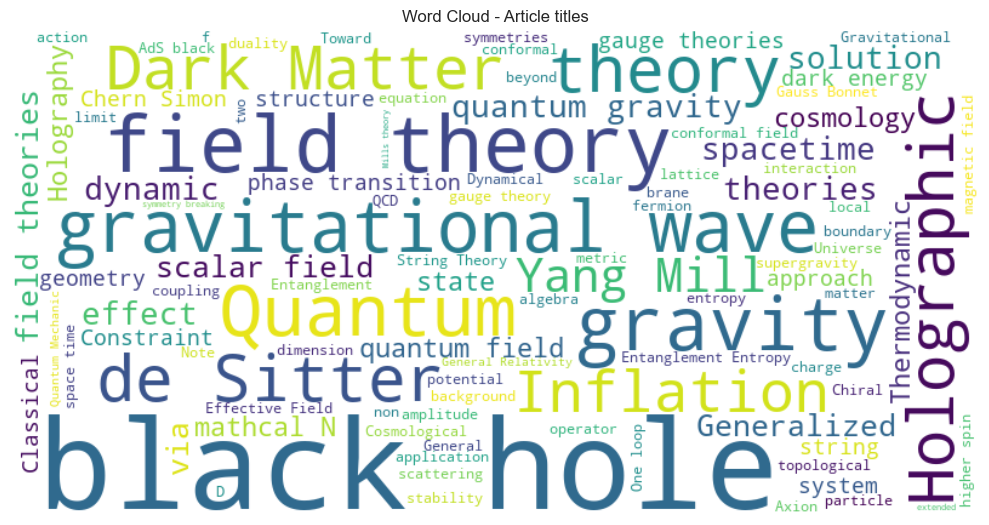

In [12]:
# Word Cloud from titles

## Join all the titles in a str
all_titles = ' '.join(df['title'].dropna().astype(str))

## Clean the text
from wordcloud import STOPWORDS
stopwords = set(STOPWORDS)
stopwords.update(['arxiv', 'study', 'using', 'analysis', 'model', 'models', 'new'])

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, max_words=100).generate(all_titles)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Article titles')
plt.tight_layout()
plt.show()

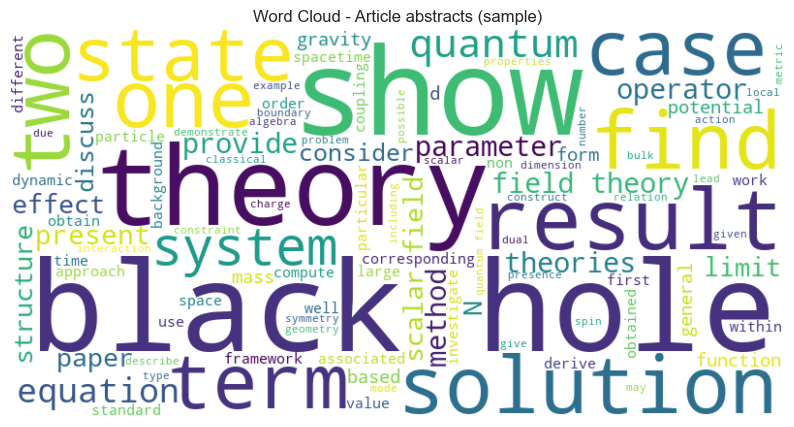

In [13]:
# Word Cloud from summaries

## Sample of 5000 sumaries as example
sample_summaries = df['summary'].dropna().sample(min(5000, len(df)))
all_summaries = ' '.join(sample_summaries)

wordcloud_sum = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, max_words=100).generate(all_summaries)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_sum, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Article abstracts (sample)')
plt.show()

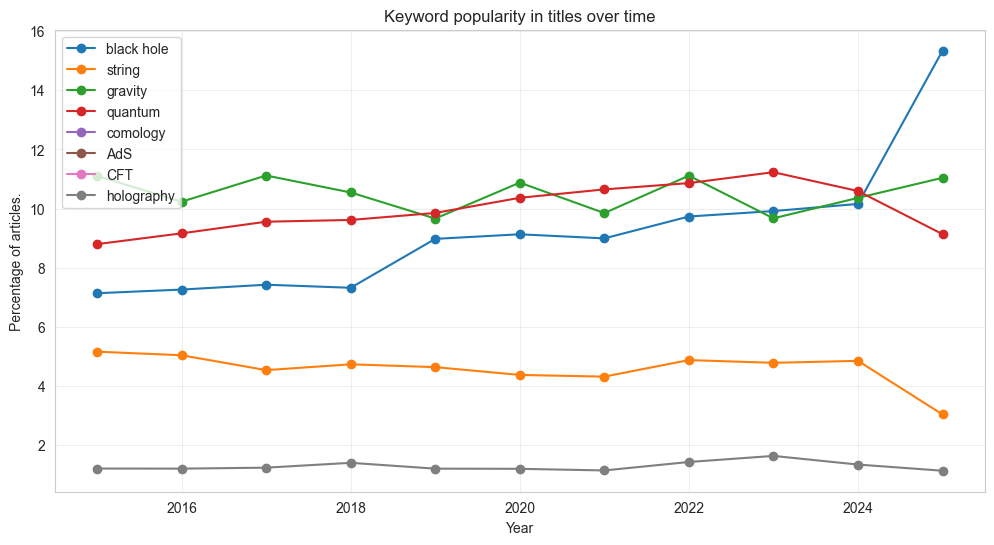

In [15]:
# Evolution of key words along the time
keywords = ['black hole', 'string', 'gravity', 'quantum', 'comology', 'AdS', 'CFT', 'holography']
df['title_lower'] = df['title'].str.lower()

# Count per year of each keyword
keyword_trend = pd.DataFrame()
for kw in keywords:
    mask = df['title_lower'].str.contains(kw, na=False)
    yearly_kw = df[mask].groupby('year').size()
    keyword_trend[kw] = yearly_kw

# Normalize by total articles per year (percentage)
total_per_year = df.groupby('year').size()
keyword_trend_pct = keyword_trend.div(total_per_year, axis=0) * 100

keyword_trend_pct.plot(marker='o', figsize=(12, 6))
plt.xlabel('Year')
plt.ylabel('Percentage of articles.')
plt.title('Keyword popularity in titles over time')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [31]:
print('=== Summary statistics ===')
print(f'Total articles: {len(df)}')
print(f'Date range: {df['published'].min().split(' ')[0]} to {df['published'].max().split(' ')[0]}')
print(f'Number of unique authors: {df['authors'].str.split(', ').explode().nunique()}')
print(f'Top primary category: {df['primary_category'].mode()[0]}')

=== Summary statistics ===
Total articles: 81011
Date range: 2015-01-01 to 2025-12-31
Number of unique authors: 54899
Top primary category: hep-th


<h1 style="color:yellow"> Part 4: NLP - Analysis and Primary Category Prediction</h1>

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
conn = sqlite3.connect('arxiv.db')
df = pd.read_sql("SELECT * FROM articles", conn)
conn.close()

print(f'Dataset: {len(df)} articles')
print(f'Unique primary categories: {df['primary_category'].nunique()}')

Dataset: 81011 articles
Unique primary categories: 108


In [10]:
# Coinsider only categories with at least 100 articles
min_samples = 100
cat_counts = df['primary_category'].value_counts()
top_cats = cat_counts[cat_counts >= min_samples].index.tolist()
print(f'Number of categories with ≥ {min_samples} articles: {len(top_cats)}')

# Filtering the DF
df_filtered = df[df['primary_category'].isin(top_cats)].copy()
print(f'Articles considered: {len(df_filtered)}')

Number of categories with ≥ 100 articles: 21
Articles considered: 79437


In [11]:
# Combining title with summary
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Removing puntuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text
df_filtered['clean_title'] = df_filtered['title'].apply(clean_text)
df_filtered['clean_summary'] = df_filtered['summary'].apply(clean_text)

# Combine clean title with clean summary
df_filtered['text'] = df_filtered['clean_title'] + " " + df_filtered['clean_summary']

In [13]:
# Training and test set
X = df_filtered['text']
y = df_filtered['primary_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 63549, Test: 15888


In [17]:
# TF-IDF vectorizer (limited to 5000 features)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
X_train_tfid = vectorizer.fit_transform(X_train)
X_test_tfid = vectorizer.transform(X_test)

print(f'TF-IDF matrix shape: {X_train_tfid.shape}')

TF-IDF matrix shape: (63549, 5000)


In [18]:
# Multi-class logistic regression model

lr = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
lr.fit(X_train_tfid, y_train)
y_pred_lr = lr.predict(X_test_tfid)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {acc_lr:.4f}')
print(classification_report(y_test, y_pred_lr))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.7672
                    precision    recall  f1-score   support

       astro-ph.CO       0.73      0.68      0.70       581
       astro-ph.GA       0.80      0.19      0.31        21
       astro-ph.HE       0.73      0.50      0.59       123
 cond-mat.mes-hall       0.60      0.37      0.46        95
cond-mat.quant-gas       0.75      0.08      0.15        37
cond-mat.stat-mech       0.55      0.35      0.43       213
   cond-mat.str-el       0.74      0.59      0.66       335
             gr-qc       0.76      0.78      0.77      3178
           hep-lat       0.77      0.63      0.69       229
            hep-ph       0.73      0.64      0.68      1268
            hep-th       0.79      0.89      0.84      8335
           math-ph       0.54      0.26      0.35       432
           math.AG       0.85      0.44      0.58       102
           math.DG       0.79      0.33      0.46        92
           math.GT       0.75      0.26      0.39        23
  

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

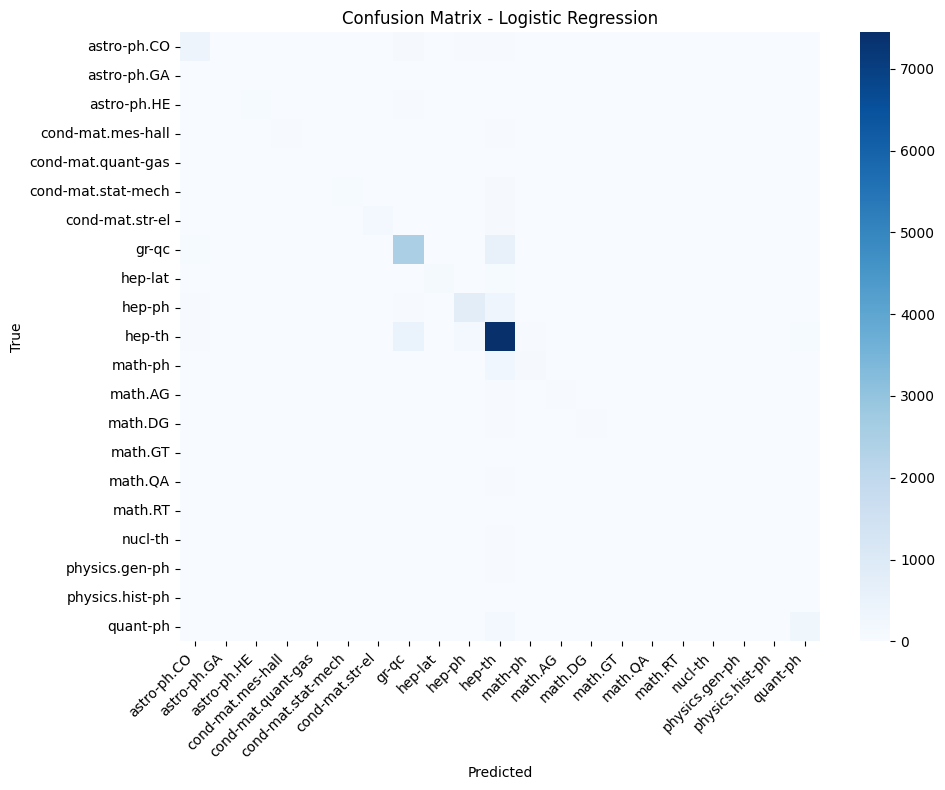

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr, labels=lr.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt='d', xticklabels=lr.classes_, yticklabels=lr.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# Random Forest Model

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_tfid, y_train)
y_pred_rf = rf.predict(X_test_tfid)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {acc_rf:.4f}')
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7195
                    precision    recall  f1-score   support

       astro-ph.CO       0.74      0.54      0.62       581
       astro-ph.GA       0.00      0.00      0.00        21
       astro-ph.HE       1.00      0.04      0.08       123
 cond-mat.mes-hall       0.67      0.06      0.12        95
cond-mat.quant-gas       0.00      0.00      0.00        37
cond-mat.stat-mech       0.80      0.02      0.04       213
   cond-mat.str-el       0.85      0.34      0.48       335
             gr-qc       0.73      0.76      0.74      3178
           hep-lat       0.79      0.33      0.47       229
            hep-ph       0.77      0.48      0.59      1268
            hep-th       0.71      0.92      0.80      8335
           math-ph       0.68      0.03      0.07       432
           math.AG       0.92      0.23      0.36       102
           math.DG       1.00      0.01      0.02        92
           math.GT       0.00      0.00      0.00        23
        

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

In [22]:
print(f"Logistic Regression accuracy: {acc_lr:.4f}")
print(f"Random Forest accuracy: {acc_rf:.4f}")

Logistic Regression accuracy: 0.7672
Random Forest accuracy: 0.7195


In [23]:
# Most important words per category (Best Model: Logistic Regression)
coef = lr.coef_
feature_names = vectorizer.get_feature_names_out()

for i, cat in enumerate(lr.classes_):
    top_idx = coef[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_idx if coef[i][j] > 0]
    print(f'\nTop words for category {cat}:')
    print(", ".join(top_words[:10]))


Top words for category astro-ph.CO:
cosmological, inflation, cosmic, primordial, cmb, constraints, dark, data, redshift, dark energy

Top words for category astro-ph.GA:
galaxies, galactic, galaxy, dark matter, stellar, supermassive, dark, supermassive black, binary, black

Top words for category astro-ph.HE:
accretion, neutrino, stars, gammaray, pulsars, binary, neutron, xray, black, star

Top words for category cond-mat.mes-hall:
graphene, topological, hall, semimetals, weyl, dirac, materials, skyrmion, quantum hall, insulators

Top words for category cond-mat.quant-gas:
boseeinstein, vortex, condensates, superfluid, gas, condensate, atoms, atomic, dynamics, quantum

Top words for category cond-mat.stat-mech:
systems, chain, nonequilibrium, ising, entanglement, exact, quenches, statistical, critical, integrable

Top words for category cond-mat.str-el:
fracton, phases, liquid, symmetry, quantum critical, topological, 21d, syk, liquids, criticality

Top words for category gr-qc:
gravi

In [24]:
# Deploying the model
def predict_category(title, summary=""):
    text = clean_text(title) + " " + clean_text(summary)
    X_new = vectorizer.transform([text])
    pred = lr.predict(X_new)[0]
    proba = lr.predict_proba(X_new)[0].max()
    return pred, proba

# Example 
example_title = 'Hairy Black Hole Entropy from Two Scalar Field Model'
cat, conf = predict_category(example_title)
print(f'Prediction: {cat} (Probability: {conf:.2f})')

Prediction: hep-th (Probability: 0.54)


<h1 style="color:yellow"> Conclusions</h1>


This project demonstrates a complete data science pipeline: from API scraping, cleaning, and database storage to exploratory visualisation and text classification. It showcases skills in **data acquisition**, **data wrangling**, **SQL**, **time‑series analysis**, **NLP**, and **model evaluation**. The Logistic Regression classifier, with 77% accuracy on a multi‑class problem, proves that even simple models can capture meaningful signals in academic texts. The code and figures are ready to be included in a professional portfolio.